# 1) import library

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

# 2) Load Dataset

In [11]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# 3) Exporing Datasets

In [12]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


# 4) Split Features and Target

In [13]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 5) Train-Test Split

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# 6) Standardized

In [23]:
Scaler=StandardScaler()
X_train_scaled =Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)


# 7) Linear Regression

In [25]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)

# 8) Evalution

In [26]:
mae =mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

# 9) Ridge

In [27]:
ridge = Ridge (alpha = 1.0)
ridge.fit(X_train_scaled, Y_train)
Y_pred_ridge = ridge.predict(X_test_scaled)

# 10) Lasso

In [28]:
lasso = Lasso (alpha = 1.0)
lasso.fit(X_train_scaled, Y_train)
Y_pred_lasso = lasso.predict(X_test_scaled)

# 11) Plot Actual vs Preditct Values

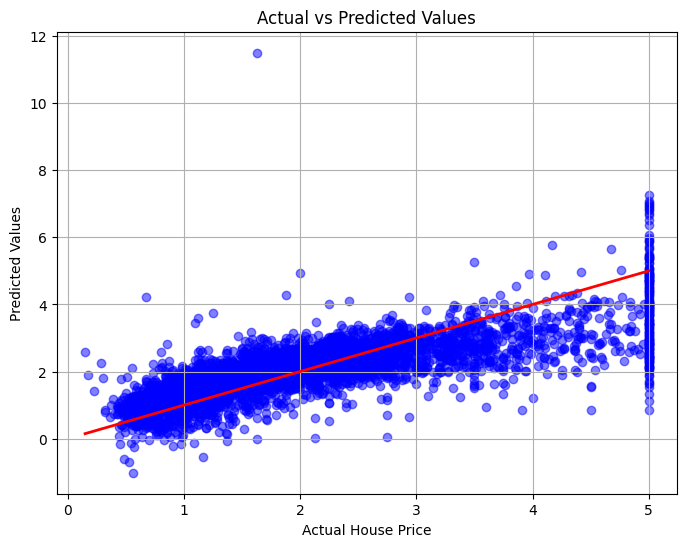

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test,Y_pred,color='blue', alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linewidth = 2)
plt.xlabel('Actual House Price')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()

# 12) Residual Polt

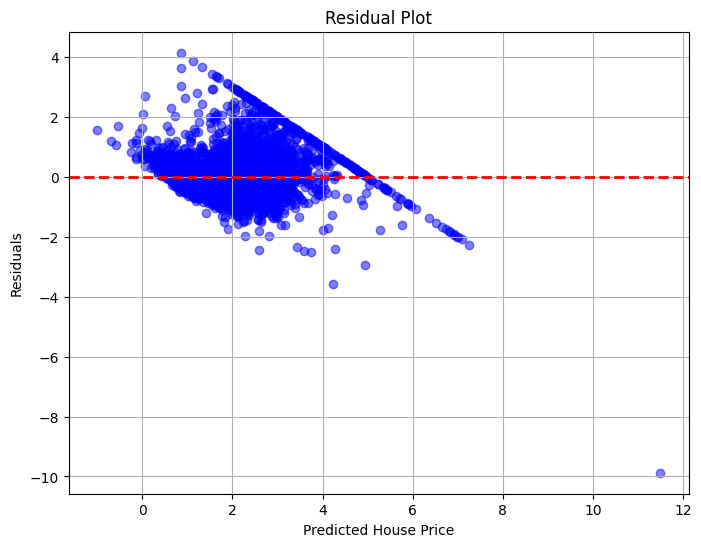

In [34]:
residuals = Y_test - Y_pred
plt.figure(figsize=(8,6))
plt.scatter(Y_pred, residuals, color='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--' ,linewidth = 2)
plt.xlabel('Predicted House Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

# 13) Compare Linear , Ridge and Graphically

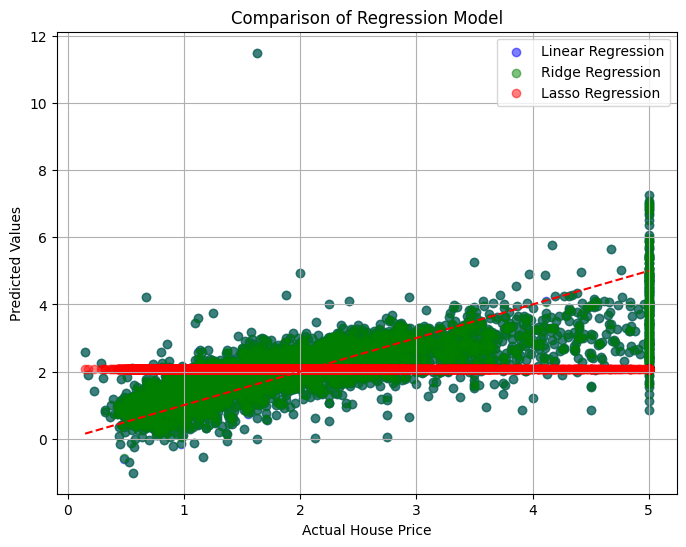

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(Y_test, Y_pred_ridge, color='green', alpha=0.5, label='Ridge Regression')
plt.scatter(Y_test, Y_pred_lasso, color='red', alpha=0.5, label='Lasso Regression')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'r--')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted Values')
plt.title('Comparison of Regression Model')
plt.legend()
plt.grid(True)
plt.show()